## Montecarlo Simulation
**Edgard Cuadra**

**Ignacio Umpierre**

**Nick Highman**

The following notebook outlines the montecarlo simulation for solar panels given the demand and weather data. 
First we look at the data, and define variables to clean it for easier handling.



In [58]:
# loading the Montecarlo Raw Data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [59]:
# Load the excel data into a pandas dataframe
df1 = pd.read_excel('Montecarlo Raw Data.xlsx', sheet_name='Energy Consumption Raw Data') 
df2 = pd.read_excel('Montecarlo Raw Data.xlsx', sheet_name='Daily Temp Average')
df3 = pd.read_excel('Montecarlo Raw Data.xlsx', sheet_name='Energy Production')


print(f"We want to look at the columns and some of the data: \n-->This is the  first data frame\n{df1.head()} \n\n-->This is the second data frame\n{df2.head()} \n\n-->This is the third data frame\n{df3.head()}")


We want to look at the columns and some of the data: 
-->This is the  first data frame
        Date  Avg Temp  kWh Delivered to Customer  Month Seasson  \
0 2022-01-01        50                     39.708      1  Winter   
1 2022-01-02        47                     31.517      1  Winter   
2 2022-01-03        27                     39.497      1  Winter   
3 2022-01-04        24                     41.692      1  Winter   
4 2022-01-05        31                     34.216      1  Winter   

   hours of light  
0        9.380556  
1        9.393056  
2        9.406667  
3        9.421111  
4        9.436667   

-->This is the second data frame
   Year  2024-01-21 00:00:00
0  2024                19.44
1  2023                35.96
2  2022                15.88
3  2021                29.25
4  2020                24.38 

-->This is the third data frame
        Date  Week Month  hrs of light  Watts_panel_hrlight  Watts produced  \
0 2023-01-01  Wk01   Jan      9.380556            67.328523   

In [60]:
# renaming the 'hours of light column in df1 to hrs of light
# df1.rename(columns = {'hours of Light':'hrs of light'}, inplace = True) 
df1.rename(columns = {'Seasson':'Season'}, inplace = True)

# looking at the columns of the dataframes
print(f"Looking at the columns for the first data frame: \n\t{df1.columns}")
print(f"Looking at the oclumns for the second data frame: \n\t{df2.columns}")
print(f"Looking at the columns for the third data frame: \n\t{df3.columns}")


Looking at the columns for the first data frame: 
	Index(['Date', 'Avg Temp', 'kWh Delivered to Customer', 'Month', 'Season',
       'hours of light'],
      dtype='object')
Looking at the oclumns for the second data frame: 
	Index(['Year', 2024-01-21 00:00:00], dtype='object')
Looking at the columns for the third data frame: 
	Index(['Date', 'Week', 'Month', 'hrs of light', 'Watts_panel_hrlight',
       'Watts produced', 'Season', 'Sun raise angle', 'Sun Dawn Angle',
       'Distance To Sun', 'Sun Angle', 'Weather Coded'],
      dtype='object')


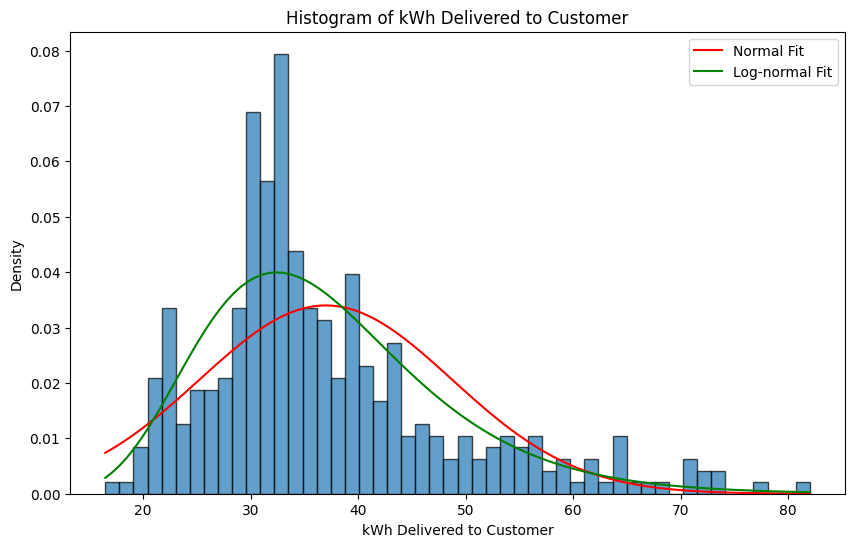

Distribution Analysis Results:
Mean: 37.00345479452055
Std Dev: 11.73474722194837
Skewness: 1.2053811038446918
Kurtosis: 1.4342849998810507
KS Test Statistic: 0.13505314318115658
KS Test p-value: 2.8780042773058407e-06
AD Test Statistic: 10.612866813423182
AD Critical Values: [0.57  0.649 0.779 0.908 1.08 ]
AD Significance Levels: [15.  10.   5.   2.5  1. ]


In [61]:
# block to figure out what kind of distribution the energy demand follows

# consumption is a function of temperature, months, and amnt of light
# temperature is nomal


# triangular distribution if montly energy demand has a clear minimum and maximum
# log normal if demand is skewed to the right
# discrete if historial data sugests clear seasonal patterns
import scipy.stats as stats


# Extracting the kWh Delivered to Customer column
energy_data = df1["kWh Delivered to Customer"].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(energy_data, bins=50, edgecolor='black', alpha=0.7, density=True)
plt.title('Histogram of kWh Delivered to Customer')
plt.xlabel('kWh Delivered to Customer')
plt.ylabel('Density')

# Fit normal distribution
mu, std = stats.norm.fit(energy_data)
x = np.linspace(min(energy_data), max(energy_data), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', label="Normal Fit")

# Fit log-normal distribution
shape, loc, scale = stats.lognorm.fit(energy_data, floc=0)
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), 'g-', label="Log-normal Fit")

# Show plot with legend
plt.legend()
plt.show()

# Compute skewness and kurtosis
skewness = stats.skew(energy_data)
kurtosis = stats.kurtosis(energy_data)

# Perform normality test
ks_stat, ks_p = stats.kstest(energy_data, 'norm', args=(mu, std))
ad_stat, ad_critical, ad_significance = stats.anderson(energy_data, 'norm')

# Print statistics
distribution_results = {
    "Mean": mu,
    "Std Dev": std,
    "Skewness": skewness,
    "Kurtosis": kurtosis,
    "KS Test Statistic": ks_stat,
    "KS Test p-value": ks_p,
    "AD Test Statistic": ad_stat,
    "AD Critical Values": ad_critical,
    "AD Significance Levels": ad_significance
}

# Print the results of the distribution analysis
print("Distribution Analysis Results:")
for i in distribution_results:
    print(f"{i}: {distribution_results[i]}")




## Histogram Analysis

1. We can see that the data does not follow a normal distribution.
2. Skewness = 1.205 --> shows a right tailed distribution.
3. Kurtosis = 1.434 --> shows a less heavy tailed than normal distributions.
4. KS Test: 
    - KS Stat: 0.135 suggests poor fit
    - Pvalue is too low meaning normal distribution is not a good fit.
5. AD Test:
    - Test Stat = 10.61 which is higher that critical values at all levels.
    - This gives strong evidence that data is not normal

Given the right skwewed nature, log normal is likely a better fit as a distribution for energy demand.


## Data Statistics
We want to look at the data statistics to use later in the data.

In [62]:
# Get statistics from power demand
power_demand_mean = df1['kWh Delivered to Customer'].mean()
power_demand_std = df1['kWh Delivered to Customer'].std()


# get statistics from solar generation
watts_produced_mean = df3['Watts produced'].mean()
watts_produced_std = df3['Watts produced'].std()
solar_generation_mean = df3['Watts_panel_hrlight'].mean()
solar_generation_std = df3['Watts_panel_hrlight'].std()


watts_per_panel_hrlight_mean = df3['Watts_panel_hrlight'].mean()
watts_per_panel_hrlight_std = df3['Watts_panel_hrlight'].std()

# calculating weather variability
weather_variability = df3['Weather Coded'].value_counts(normalize=True).to_dict()

# get hrs_of_light statistics
hrs_of_light_mean = df1['hours of light'].mean()
hrs_of_light_std = df1['hours of light'].std()


print(f'Weather variability: \n{weather_variability}')
print(f'Hours of light mean: {hrs_of_light_mean}, Hours of light std: {hrs_of_light_std}')
print(f'Power demand mean: {power_demand_mean}, Power demand std: {power_demand_std}')
print(f'Watts produced mean: {watts_produced_mean}, Watts produced std: {watts_produced_std}')
print(f'Solar generation mean: {solar_generation_mean}, Solar generation std: {solar_generation_std}')
print(f'Watts per panel per hour of light mean: {watts_per_panel_hrlight_mean}, Watts per panel per hour of light std: {watts_per_panel_hrlight_std}')

Weather variability: 
{'Good': 0.32132963988919666, 'Average': 0.29916897506925205, 'Bad': 0.2631578947368421, 'Extreme Bad': 0.05817174515235457, 'Excellent': 0.05817174515235457}
Hours of light mean: 12.218682648401826, Hours of light std: 1.9910343886540398
Power demand mean: 37.00345479452055, Power demand std: 11.750855324550965
Watts produced mean: 973.6898781503262, Watts produced std: 521.9841339097212
Solar generation mean: 76.74597972459313, Solar generation std: 34.86242004578992
Watts per panel per hour of light mean: 76.74597972459313, Watts per panel per hour of light std: 34.86242004578992


In [63]:
# Pre-calculate all necessary statistics for simulation
# This avoids df.groupby('Month') operations during simulation

# For temperature data (df2 has a different structure than expected)
# We need to transpose df2 and extract temperature by month
temp_by_month = {}

# Based on your data preview, df2 seems to be structured differently
# We need to create a new approach to get monthly temperature data
# For now, I'll use a fallback approach using df1's Avg Temp

# Extract month numbers from df1 and df3
df1_months = sorted(df1['Month'].unique())
df3_months = df3['Month'].unique()  # This seems to have month names like 'Jan'

# Create mapping from month names to numbers if needed
month_name_to_number = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Convert df3 month names to numbers for consistency
df3['MonthNumber'] = df3['Month'].map(month_name_to_number)

# Create monthly statistics dictionaries
monthly_stats = {}

# Temperature statistics by month (using df1 since df2 structure is different)
temp_avg_by_month = {}
temp_std_by_month = {}

for month in df1_months:
    month_data = df1[df1['Month'] == month]
    temp_avg_by_month[month] = month_data['Avg Temp'].mean()
    temp_std_by_month[month] = month_data['Avg Temp'].std()
    if pd.isna(temp_std_by_month[month]) or temp_std_by_month[month] == 0:
        temp_std_by_month[month] = 1.0  # Default standard deviation if data is insufficient

# Sunlight hours statistics by month
sunlight_avg_by_month = {}
sunlight_std_by_month = {}

for month in df1_months:
    month_data = df1[df1['Month'] == month]
    # Use the corrected column name 'hrs of light' instead of 'hours of light'
    sunlight_avg_by_month[month] = month_data['hours of light'].mean() 
    sunlight_std_by_month[month] = month_data['hours of light'].std()
    if pd.isna(sunlight_std_by_month[month]) or sunlight_std_by_month[month] == 0:
        sunlight_std_by_month[month] = 0.1  # Default standard deviation if data is insufficient

# Check if we have all 12 months
for month in range(1, 13):
    if month not in sunlight_avg_by_month:
        print(f"Warning: No data for month {month}, using estimates")
        # Use reasonable defaults or adjacent months
        if month-1 in sunlight_avg_by_month:
            sunlight_avg_by_month[month] = sunlight_avg_by_month[month-1]
            sunlight_std_by_month[month] = sunlight_std_by_month[month-1]
        elif month+1 in sunlight_avg_by_month:
            sunlight_avg_by_month[month] = sunlight_avg_by_month[month+1]
            sunlight_std_by_month[month] = sunlight_std_by_month[month+1]
        else:
            # Default values if no adjacent months
            sunlight_avg_by_month[month] = 12  # Reasonable average
            sunlight_std_by_month[month] = 1   # Reasonable std dev

# Print the computed statistics to verify
print("Monthly temperature averages:", temp_avg_by_month)
print("Monthly sunlight hours averages:", sunlight_avg_by_month)

Monthly temperature averages: {np.int64(1): np.float64(25.70967741935484), np.int64(2): np.float64(32.82142857142857), np.int64(3): np.float64(42.16129032258065), np.int64(4): np.float64(49.666666666666664), np.int64(5): np.float64(63.064516129032256), np.int64(6): np.float64(69.16666666666667), np.int64(7): np.float64(76.7741935483871), np.int64(8): np.float64(75.74193548387096), np.int64(9): np.float64(64.93333333333334), np.int64(10): np.float64(51.87096774193548), np.int64(11): np.float64(45.3), np.int64(12): np.float64(33.193548387096776)}
Monthly sunlight hours averages: {np.int64(1): np.float64(9.702177419354838), np.int64(2): np.float64(10.664623015873017), np.int64(3): np.float64(11.913216845878134), np.int64(4): np.float64(13.262712962962963), np.int64(5): np.float64(14.421209677419354), np.int64(6): np.float64(15.029694444444447), np.int64(7): np.float64(14.770125448028674), np.int64(8): np.float64(13.784856630824374), np.int64(9): np.float64(12.505212962962963), np.int64(10

## Montecarlo Methodology

In [64]:
# Add this function to calculate energy demand based on temperature and month
def calculate_energy_demand(month, temperature):
    """Calculate energy demand based on regression equations for each month."""
    if month == 1:
        return 28.27 + 0.976*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 2:
        return 28.2 + 1.001*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 3:
        return 34.6 + 0.884*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 4:
        return 44.8 + 0.616*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 5:
        return 56.3 + 0.434*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 6:
        return 71.9 + 0.074*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 7:
        return 216.3 - 1.572*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 8:
        return 41.6 + 0.716*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 9:
        return 42.9 + 0.723*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 10:
        return 19.6 + 1.143*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    elif month == 11:
        return 33.8 + 0.718*temperature - 0.0377*temperature**2 + 0.000400*temperature**3
    else:  # month == 12
        return 15.35 + 1.114*temperature - 0.0377*temperature**2 + 0.000400*temperature**3

In [65]:
# Function to simulate sunlight hours using pre-calculated statistics
def simulate_sunlight_hours(month):
    """Simulate sunlight hours for a specific month based on pre-calculated statistics."""
    # Get the monthly average and std from pre-calculated dictionaries
    if month in sunlight_avg_by_month:
        monthly_avg = sunlight_avg_by_month[month]
        monthly_std = sunlight_std_by_month[month]
    else:
        # Fallback if we don't have data for this month
        print(f"Warning: No sunlight data for month {month}, using overall average")
        monthly_avg = df1['hours of light'].mean()
        monthly_std = df1['hours of light'].std() if df1['hours of light'].std() > 0 else 0.1
    
    # For variation, use a triangular distribution (min, mode, max)
    lower_bound = max(0, monthly_avg - 1.5*monthly_std)
    upper_bound = monthly_avg + 1.5*monthly_std
    
    return np.random.triangular(lower_bound, monthly_avg, upper_bound)

In [ ]:
# Updated function to avoid errors
def analyze_sunlight_distribution():
    """Analyze and visualize the distribution of sunlight hours by month."""
    plt.figure(figsize=(14, 8))
    
    for month in range(1, 13):
        plt.subplot(3, 4, month)
        
        try:
            # Get data for this month
            month_data = df1[df1['Month'] == month]['hours of light']
            
            if len(month_data) >= 3:  # Need at least 3 points for meaningful histogram
                # Plot histogram
                plt.hist(month_data, bins=min(10, len(month_data)), alpha=0.7)
                
                # Plot normal distribution fit
                mu, std = stats.norm.fit(month_data)
                if std > 0:  # Avoid division by zero
                    x = np.linspace(min(month_data), max(month_data), 100)
                    plt.plot(x, stats.norm.pdf(x, mu, std) * len(month_data) * (max(month_data)-min(month_data))/min(10, len(month_data)), 
                            'r-', label="Normal Fit")
                
                # Add statistics
                plt.title(f"Month {month}")
                if month == 1:  # Only add legend to first plot
                    plt.legend()
            else:
                plt.title(f"Month {month} - Insufficient data")
                
        except Exception as e:
            plt.title(f"Month {month} - Error")
            print(f"Error plotting month {month}: {e}")
    
    plt.tight_layout()
    plt.suptitle("Sunlight Hours Distribution by Month", fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.savefig("sunlight_distribution.png")
    plt.show()
    
    # Perform formal statistical tests for normality
    print("Shapiro-Wilk Test Results for Sunlight Hours by Month:")
    for month in range(1, 13):
        try:
            month_data = df1[df1['Month'] == month]['hours of light']
            if len(month_data) >= 3:  # Need at least 3 samples for Shapiro-Wilk test
                stat, p = stats.shapiro(month_data)
                normal = "Normal" if p > 0.05 else "Not Normal"
                print(f"Month {month}: W={stat:.4f}, p={p:.4f} -> {normal}")
            else:
                print(f"Month {month}: Insufficient data for normality test")
        except Exception as e:
            print(f"Month {month}: Error in normality test - {e}")

analyze_sunlight_distribution()

In [ ]:
weather_multiplier = {
    'Good': 1.2,
    'Average': 1.0,
    'Bad': 0.6,
    'Extreme Bad': 0.2
}

def run_simulation(num_panels, years=30, iterations=1000):
    """
    Run a Monte Carlo simulation to generate the distribution of ratios
    for a fixed number of panels.
    
    Returns:
        List of production/consumption ratios
    """
    all_ratios = []
    
    for _ in range(iterations):
        yearly_consumption = 0
        yearly_production = 0
        
        for month in range(1, 13):
            # Simulate temperature using pre-calculated statistics
            if month in temp_avg_by_month:
                temperature = np.random.normal(
                    temp_avg_by_month[month],
                    temp_std_by_month[month]
                )
            else:
                # Fallback - use overall temperature mean and std
                temperature = np.random.normal(
                    df1['Avg Temp'].mean(),
                    df1['Avg Temp'].std() if df1['Avg Temp'].std() > 0 else 5.0
                )
            
            # Calculate consumption using regression equation
            consumption = calculate_energy_demand(month, temperature)
            yearly_consumption += consumption
            
            # Calculate production with better sunlight model
            sunlight_hours = simulate_sunlight_hours(month)
            
            # Weather effect
            weather = np.random.choice(
                list(weather_variability.keys()),
                p=list(weather_variability.values())
            )
            weather_factor = weather_multiplier[weather]
            
            # Calculate production for this month
            monthly_production = (
                num_panels *
                watts_per_panel_hrlight_mean *
                sunlight_hours *
                weather_factor / 1000
            )
            yearly_production += monthly_production
        
        # Calculate ratio for this year as a percentage
        if yearly_consumption > 0:
            ratio = (yearly_production / yearly_consumption) * 100
            all_ratios.append(ratio)
    
    return all_ratios

In [ ]:
# Run the simulation with error handling
try:
    print("Starting Monte Carlo simulation with error handling...")
    run_simulation(40)
except Exception as e:
    import traceback
    print(f"Error occurred during simulation: {e}")
    traceback.print_exc()
    
    print("\nAttempting to identify and fix the issue...")
    # Add diagnostics about the data
    print("\nData diagnostics:")
    print(f"df1 shape: {df1.shape}, missing values: {df1.isna().sum().sum()}")
    print(f"df2 shape: {df2.shape}, missing values: {df2.isna().sum().sum()}")
    print(f"df3 shape: {df3.shape}, missing values: {df3.isna().sum().sum()}")

Starting Monte Carlo simulation with error handling...
Error occurred during simulation: np.str_('Excellent')

Attempting to identify and fix the issue...

Data diagnostics:
df1 shape: (365, 6), missing values: 0
df2 shape: (30, 2), missing values: 0
df3 shape: (361, 13), missing values: 0


Traceback (most recent call last):
  File "C:\Users\edgar\AppData\Local\Temp\ipykernel_7628\3444924973.py", line 4, in <module>
    run_simulation(40)
  File "C:\Users\edgar\AppData\Local\Temp\ipykernel_7628\1455607.py", line 48, in run_simulation
    weather_factor = weather_multiplier[weather]
                     ~~~~~~~~~~~~~~~~~~^^^^^^^^^
KeyError: np.str_('Excellent')
